In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

In [3]:
IMAGE_SIZE = 256
CHANNELS = 3

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True
)
train_generator = train_datagen.flow_from_directory(
        'dataset/train',
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=32,
        class_mode="sparse",
#         save_to_dir="C:\\Code\\potato-disease-classification\\training\\AugmentedImages"
)

Found 1506 images belonging to 3 classes.


In [5]:
train_generator.class_indices

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}

In [6]:
class_names = list(train_generator.class_indices.keys())
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [7]:

count=0
for image_batch, label_batch in train_generator:
#     print(label_batch)
    print(image_batch[0])
    break
#     count+=1
#     if count>2:
#         break

[[[0.6308599  0.5798795  0.6190952 ]
  [0.6327951  0.5818147  0.6210304 ]
  [0.6347304  0.58375    0.6229657 ]
  ...
  [0.5684353  0.51745486 0.5566706 ]
  [0.58241916 0.53143877 0.57065445]
  [0.5813067  0.5303263  0.569542  ]]

 [[0.58100945 0.53002906 0.56924474]
  [0.59197587 0.5409955  0.58021116]
  [0.6029424  0.551962   0.5911777 ]
  ...
  [0.57037055 0.51939017 0.55860585]
  [0.5856446  0.5346642  0.5738799 ]
  [0.57292056 0.5219402  0.56115586]]

 [[0.5875687  0.5365883  0.575804  ]
  [0.58111787 0.5301375  0.56935316]
  [0.574667   0.5236866  0.5629023 ]
  ...
  [0.5723058  0.5213254  0.5605411 ]
  [0.58887005 0.53788966 0.57710534]
  [0.5645344  0.51355404 0.5527697 ]]

 ...

 [[0.66237754 0.6192403  0.65061283]
  [0.6701848  0.62704754 0.6584201 ]
  [0.6627451  0.61960787 0.6509804 ]
  ...
  [0.5451692  0.5137966  0.564777  ]
  [0.5561356  0.52476305 0.57574344]
  [0.5671021  0.5357295  0.5867099 ]]

 [[0.665603   0.6224657  0.6538383 ]
  [0.66824955 0.6251123  0.65648484]


In [8]:
validation_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True)
validation_generator = validation_datagen.flow_from_directory(
        'dataset/val',
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=32,
        class_mode="sparse"
)

Found 215 images belonging to 3 classes.


In [9]:
test_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True)

test_generator = test_datagen.flow_from_directory(
        'dataset/test',
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=32,
        class_mode="sparse"
)

Found 431 images belonging to 3 classes.


In [10]:
for image_batch, label_batch in test_generator:
    print(image_batch[0])
    break

[[[0.54034567 0.5128947  0.54426724]
  [0.5433724  0.5159214  0.54729396]
  [0.5463992  0.5189482  0.55032074]
  ...
  [0.38684574 0.35939476 0.3907673 ]
  [0.3689844  0.34153342 0.37290597]
  [0.35248923 0.32503825 0.3564108 ]]

 [[0.5192167  0.4917657  0.5231383 ]
  [0.51588726 0.48843622 0.5198088 ]
  [0.51255774 0.48510677 0.5164794 ]
  ...
  [0.38593772 0.35848674 0.3898593 ]
  [0.36747104 0.34002006 0.3713926 ]
  [0.3512785  0.32382753 0.35520008]]

 [[0.5478772  0.5204262  0.55179876]
  [0.5496932  0.52224225 0.5536148 ]
  [0.5515093  0.52405834 0.5554309 ]
  ...
  [0.38502967 0.3575787  0.38895124]
  [0.36595765 0.33850664 0.36987922]
  [0.3500678  0.32261682 0.35398936]]

 ...

 [[0.56078434 0.5372549  0.58431375]
  [0.56028366 0.53675425 0.5838131 ]
  [0.551748   0.52821857 0.5752774 ]
  ...
  [0.44289863 0.41544765 0.44682023]
  [0.44259596 0.41514498 0.44651753]
  [0.4422933  0.4148423  0.44621485]]

 [[0.56078434 0.5372549  0.58431375]
  [0.5596783  0.5361489  0.5832077 ]


In [11]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 64)        0

In [13]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [14]:
1506/32

47.0625

In [15]:
215/32

6.71875

In [16]:
history = model.fit(
    train_generator,
    steps_per_epoch=47,
    batch_size=32,
    validation_data=validation_generator,
    validation_steps=6,
    verbose=1,
    epochs=20,
)

Epoch 1/20


47/47 [==============================] - 54s 1s/step - loss: 0.8980 - accuracy: 0.5068 - val_loss: 0.8223 - val_accuracy: 0.6562
Epoch 2/20
47/47 [==============================] - 29s 611ms/step - loss: 0.5904 - accuracy: 0.7402 - val_loss: 0.4323 - val_accuracy: 0.8073
Epoch 3/20
47/47 [==============================] - 29s 616ms/step - loss: 0.3376 - accuracy: 0.8643 - val_loss: 0.3526 - val_accuracy: 0.8438
Epoch 4/20
47/47 [==============================] - 29s 612ms/step - loss: 0.3350 - accuracy: 0.8677 - val_loss: 0.2699 - val_accuracy: 0.8958
Epoch 5/20
47/47 [==============================] - 29s 622ms/step - loss: 0.2488 - accuracy: 0.9043 - val_loss: 0.6953 - val_accuracy: 0.6250
Epoch 6/20
47/47 [==============================] - 31s 663ms/step - loss: 0.3521 - accuracy: 0.8474 - val_loss: 0.3028 - val_accuracy: 0.8594
Epoch 7/20
47/47 [==============================] - 31s 647ms/step - loss: 0.1973 - accuracy: 0.9172 - val_loss: 0.3088 - val_accuracy: 0.8594


In [17]:
scores = model.evaluate(test_generator)

14/14 [==============================] - 12s 867ms/step - loss: 0.1844 - accuracy: 0.9420


In [18]:
scores

[0.18436451256275177, 0.94199538230896]

In [19]:
history

In [20]:
history.params

{'verbose': 1, 'epochs': 20, 'steps': 47}

In [21]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [22]:
type(history.history['loss'])

list

In [23]:
len(history.history['loss'])

20

In [24]:
history.history['loss'][:5] # show loss for first 5 epochs

[0.897979199886322,
 0.5904415845870972,
 0.33761945366859436,
 0.335021436214447,
 0.2488332986831665]

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [26]:
val_acc

[0.65625,
 0.8072916865348816,
 0.84375,
 0.8958333134651184,
 0.625,
 0.859375,
 0.859375,
 0.921875,
 0.953125,
 0.9479166865348816,
 0.9427083134651184,
 0.9166666865348816,
 0.890625,
 0.9479166865348816,
 0.90625,
 0.953125,
 0.96875,
 0.9583333134651184,
 0.9583333134651184,
 0.9635416865348816]

In [27]:
acc

[0.5067842602729797,
 0.7401628494262695,
 0.8643147945404053,
 0.8677068948745728,
 0.9043419361114502,
 0.8473541140556335,
 0.9172320365905762,
 0.9321573972702026,
 0.9504749178886414,
 0.9545454382896423,
 0.9233378767967224,
 0.9497964978218079,
 0.9552238583564758,
 0.9335142374038696,
 0.9694707989692688,
 0.9660786986351013,
 0.9518317580223083,
 0.9620081186294556,
 0.9735413789749146,
 0.9654002785682678]

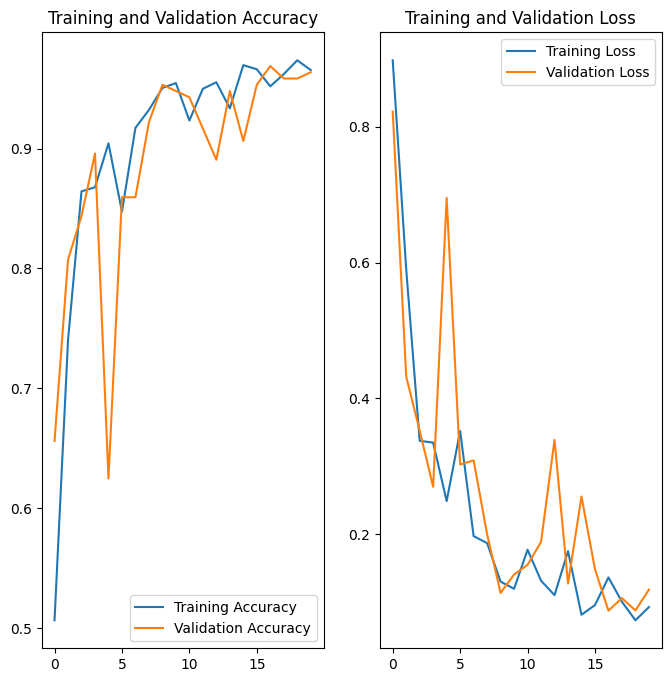

In [28]:
EPOCHS = 20

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Potato___Late_blight
1/1 [==============================] - 0s 281ms/step
predicted label: Potato___Late_blight


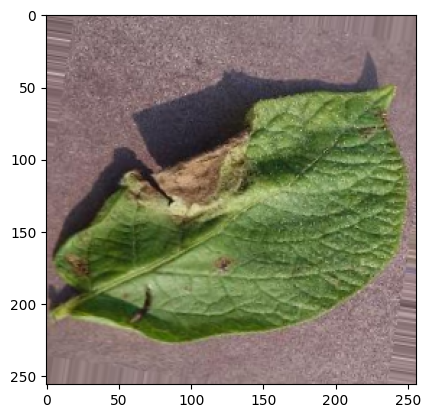

In [29]:
import numpy as np


for image_batch, label_batch in test_generator:
    first_image = image_batch[0]
    first_label = int(label_batch[0])
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(image_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])
    
    break

In [30]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i])
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 36ms/step


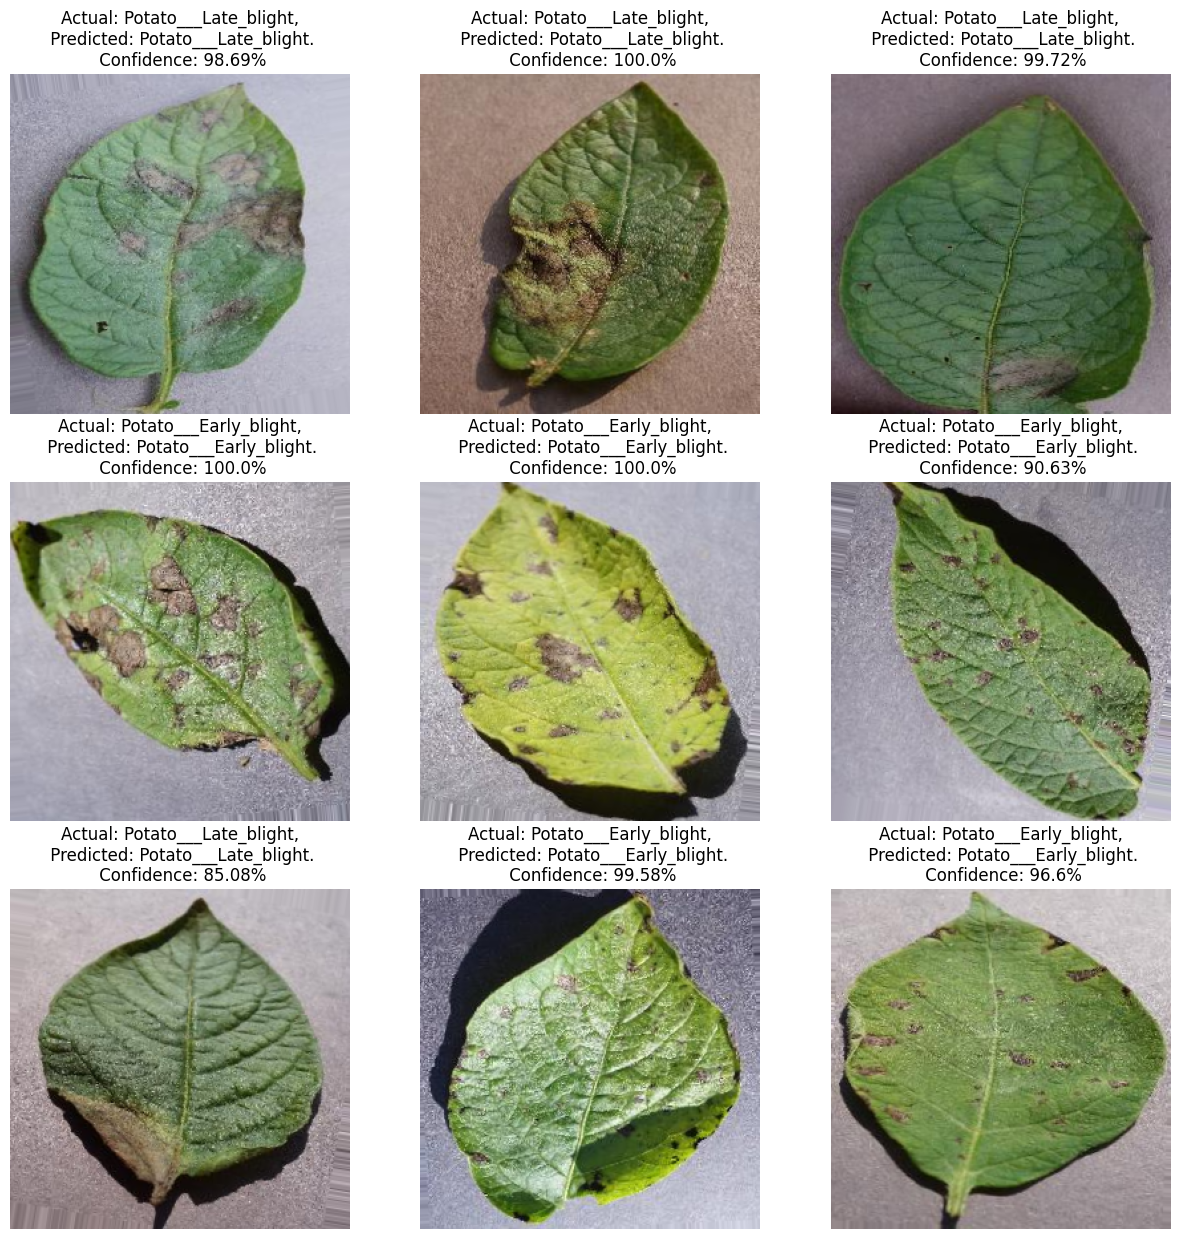

In [31]:
plt.figure(figsize=(15, 15))
for images, labels in test_generator:
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        
        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[int(labels[i])] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")
    break

In [32]:
model.save("../potatoes.h5")

c:\Users\anand\OneDrive\Alliance University\NNDL\Potato-Disease-Classification\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
